#Impot Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Data

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/RachmasariAR/Pelatihan4_DS/refs/heads/main/_dataset_pesanan.csv')
df

,ID Pelanggan,Nama,Jenis Kelamin,Makanan,Harga Makanan,Minuman,Harga Minuman,Total Bayar,Review
0,1,Nisa,P,Ayam bakar,16000.0,Jus,5000.0,21000,4.0
1,2,Isvi,P,Ayam geprek,16000.0,Es teler,7000.0,23000,5.0
2,3,Nawa,L,Nila bakar,15000.0,Es jeruk,4000.0,19000,3.0
3,4,Zayga,L,Ayam goreng,15000.0,Es buah,8000.0,23000,4.0
4,5,Dekhsa,L,Ayam geprek,16000.0,Es jeruk,4000.0,20000,5.0
5,6,Ulil,L,Lele goreng,11000.0,Es teh,3000.0,14000,2.0
6,7,Nibras,L,Lele bakar,12000.0,Es teh,3000.0,15000,1.0
7,8,Alwy,L,Ayam bakar,16000.0,Jus,5000.0,21000,4.0
8,9,Egi,L,Ayam bakar,16000.0,Es teler,7000.0,23000,3.0
9,10,Naufal,L,Nila bakar,15000.0,Es buah,8000.0,23000,5.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID Pelanggan   34 non-null     int64  
 1   Nama           34 non-null     object 
 2   Jenis Kelamin  34 non-null     object 
 3   Makanan        34 non-null     object 
 4   Harga Makanan  33 non-null     float64
 5   Minuman        34 non-null     object 
 6   Harga Minuman  33 non-null     float64
 7   Total Bayar    34 non-null     int64  
 8   Review         32 non-null     float64
dtypes: float64(3), int64(2), object(4)
memory usage: 2.5+ KB


Terdapat 4 tabel dengan tipe data object, 2 tabel dengan tipe data integer, dan 3 tabel dengan tipe data float.

In [ ]:
df.describe()

,ID Pelanggan,Harga Makanan,Harga Minuman,Total Bayar,Review
count,34.000000,33.000000,33.000000,34.000000,32.000000
mean,15.882353,14727.272727,5060.606061,19705.882353,3.343750
std,9.460491,1586.519919,1853.027825,2736.170867,1.095721
min,1.000000,11000.000000,3000.000000,14000.000000,1.000000
25%,8.250000,14000.000000,4000.000000,18000.000000,3.000000
50%,15.500000,15000.000000,4000.000000,20000.000000,3.000000
75%,23.750000,16000.000000,7000.000000,21750.000000,4.000000
max,32.000000,16000.000000,8000.000000,24000.000000,5.000000


#Cleaning Data

##Handle Missing Value

In [ ]:
df.isnull().sum()

,0
ID Pelanggan,0
Nama,0
Jenis Kelamin,0
Makanan,0
Harga Makanan,1
Minuman,0
Harga Minuman,1
Total Bayar,0
Review,2


##Mengetahui Data Null

In [ ]:
null_data = df[df.isnull().any(axis=1)]
null_data

,ID Pelanggan,Nama,Jenis Kelamin,Makanan,Harga Makanan,Minuman,Harga Minuman,Total Bayar,Review
10,11,Nico,L,Nila goreng,NaN,Es teh,3000.0,17000,3.0
15,16,Difa,L,Nila goreng,14000.0,Es teh,NaN,17000,4.0
20,20,Salman,L,Ayam geprek,16000.0,Jus,5000.0,21000,NaN
23,23,Tasya,P,Nila bakar,15000.0,Es buah,8000.0,23000,NaN


In [ ]:
df.loc[10, 'Harga Makanan'] = 14000
df.loc[15, 'Harga Minuman'] = 3000
df['Review'].fillna(df['Review'].median(), inplace=True)
df

<ipython-input-9-5acbc1f446dd>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Review'].fillna(df['Review'].median(), inplace=True)


,ID Pelanggan,Nama,Jenis Kelamin,Makanan,Harga Makanan,Minuman,Harga Minuman,Total Bayar,Review
0,1,Nisa,P,Ayam bakar,16000.0,Jus,5000.0,21000,4.0
1,2,Isvi,P,Ayam geprek,16000.0,Es teler,7000.0,23000,5.0
2,3,Nawa,L,Nila bakar,15000.0,Es jeruk,4000.0,19000,3.0
3,4,Zayga,L,Ayam goreng,15000.0,Es buah,8000.0,23000,4.0
4,5,Dekhsa,L,Ayam geprek,16000.0,Es jeruk,4000.0,20000,5.0
5,6,Ulil,L,Lele goreng,11000.0,Es teh,3000.0,14000,2.0
6,7,Nibras,L,Lele bakar,12000.0,Es teh,3000.0,15000,1.0
7,8,Alwy,L,Ayam bakar,16000.0,Jus,5000.0,21000,4.0
8,9,Egi,L,Ayam bakar,16000.0,Es teler,7000.0,23000,3.0
9,10,Naufal,L,Nila bakar,15000.0,Es buah,8000.0,23000,5.0


In [ ]:
df.isnull().sum()

,0
ID Pelanggan,0
Nama,0
Jenis Kelamin,0
Makanan,0
Harga Makanan,0
Minuman,0
Harga Minuman,0
Total Bayar,0
Review,0


In [ ]:
df.duplicated().sum()

2

In [ ]:
df_duplicated = df[df.duplicated(subset='ID Pelanggan')]
df_duplicated

,ID Pelanggan,Nama,Jenis Kelamin,Makanan,Harga Makanan,Minuman,Harga Minuman,Total Bayar,Review
17,3,Nawa,L,Nila bakar,15000.0,Es jeruk,4000.0,19000,3.0
33,9,Egi,L,Ayam bakar,16000.0,Es teler,7000.0,23000,3.0


In [ ]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

#Analisis Statistik Dasar

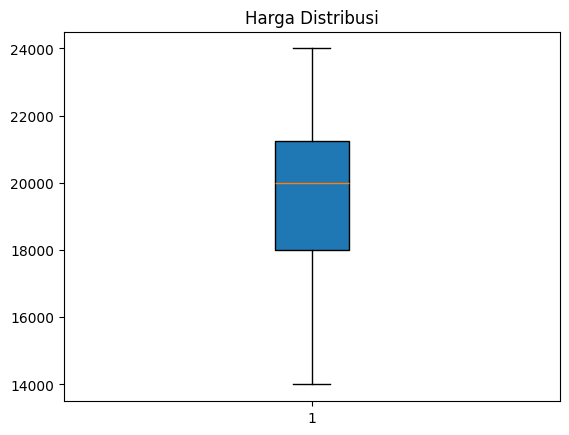

In [ ]:
box_plot_data = df['Total Bayar']
plt.title("Harga Distribusi")
plt.boxplot(box_plot_data, patch_artist=True, label=['Total Bayar'])
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 0 to 32
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID Pelanggan   32 non-null     int64  
 1   Nama           32 non-null     object 
 2   Jenis Kelamin  32 non-null     object 
 3   Makanan        32 non-null     object 
 4   Harga Makanan  32 non-null     float64
 5   Minuman        32 non-null     object 
 6   Harga Minuman  32 non-null     float64
 7   Total Bayar    32 non-null     int64  
 8   Review         32 non-null     float64
dtypes: float64(3), int64(2), object(4)
memory usage: 2.5+ KB


In [ ]:
df['Makanan'].value_counts()

,count
Makanan,
Ayam geprek,7
Nila bakar,6
Ayam bakar,5
Nila goreng,5
Ayam goreng,4
Lele goreng,3
Lele bakar,2


In [ ]:
makanan_rep = {'Ayam geprek':0, 'Nila bakar':1, 'Ayam bakar':2, 'Nila goreng':3, 'Ayam goreng':4, 'Lele goreng':5,  'Lele bakar':6}
df = df.replace({'Makanan':makanan_rep})
df.head(6)

<ipython-input-17-85e2a35ec651>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Makanan':makanan_rep})


,ID Pelanggan,Nama,Jenis Kelamin,Makanan,Harga Makanan,Minuman,Harga Minuman,Total Bayar,Review
0,1,Nisa,P,2,16000.0,Jus,5000.0,21000,4.0
1,2,Isvi,P,0,16000.0,Es teler,7000.0,23000,5.0
2,3,Nawa,L,1,15000.0,Es jeruk,4000.0,19000,3.0
3,4,Zayga,L,4,15000.0,Es buah,8000.0,23000,4.0
4,5,Dekhsa,L,0,16000.0,Es jeruk,4000.0,20000,5.0
5,6,Ulil,L,5,11000.0,Es teh,3000.0,14000,2.0


In [ ]:
df['Minuman'].value_counts()

,count
Minuman,
Es teh,9
Es jeruk,8
Jus,5
Es teler,5
Es buah,5


In [ ]:
minuman_rep ={'Es teh':0, 'Es jeruk':1, 'Jus':2, 'Es teler':3, 'Es buah':4}
df = df.replace({'Minuman':minuman_rep})
df.tail(6)

,ID Pelanggan,Nama,Jenis Kelamin,Makanan,Harga Makanan,Minuman,Harga Minuman,Total Bayar,Review
27,27,Figo,L,0,16000.0,0,3000.0,19000,2.0
28,28,Dinda,P,3,14000.0,1,4000.0,18000,4.0
29,29,Faris,L,5,11000.0,0,3000.0,14000,2.0
30,30,Wahyu,L,1,15000.0,0,3000.0,18000,3.0
31,31,Humam,L,0,16000.0,1,4000.0,20000,4.0
32,32,Adib,L,2,16000.0,4,8000.0,24000,3.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 0 to 32
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID Pelanggan   32 non-null     int64  
 1   Nama           32 non-null     object 
 2   Jenis Kelamin  32 non-null     object 
 3   Makanan        32 non-null     int64  
 4   Harga Makanan  32 non-null     float64
 5   Minuman        32 non-null     int64  
 6   Harga Minuman  32 non-null     float64
 7   Total Bayar    32 non-null     int64  
 8   Review         32 non-null     float64
dtypes: float64(3), int64(4), object(2)
memory usage: 2.5+ KB


In [ ]:
data_relationship = df.drop(['Nama', 'Jenis Kelamin'], axis='columns')
data_relationship.corr()

,ID Pelanggan,Makanan,Harga Makanan,Minuman,Harga Minuman,Total Bayar,Review
ID Pelanggan,1.000000,0.043639,-0.102178,-0.141062,-0.134808,-0.150962,-0.152208
Makanan,0.043639,1.000000,-0.806261,-0.171251,-0.151818,-0.570892,-0.271448
Harga Makanan,-0.102178,-0.806261,1.000000,0.295202,0.254613,0.753183,0.345883
Minuman,-0.141062,-0.171251,0.295202,1.000000,0.992342,0.846234,0.218828
Harga Minuman,-0.134808,-0.151818,0.254613,0.992342,1.000000,0.827902,0.193827
Total Bayar,-0.150962,-0.570892,0.753183,0.846234,0.827902,1.000000,0.332455
Review,-0.152208,-0.271448,0.345883,0.218828,0.193827,0.332455,1.000000


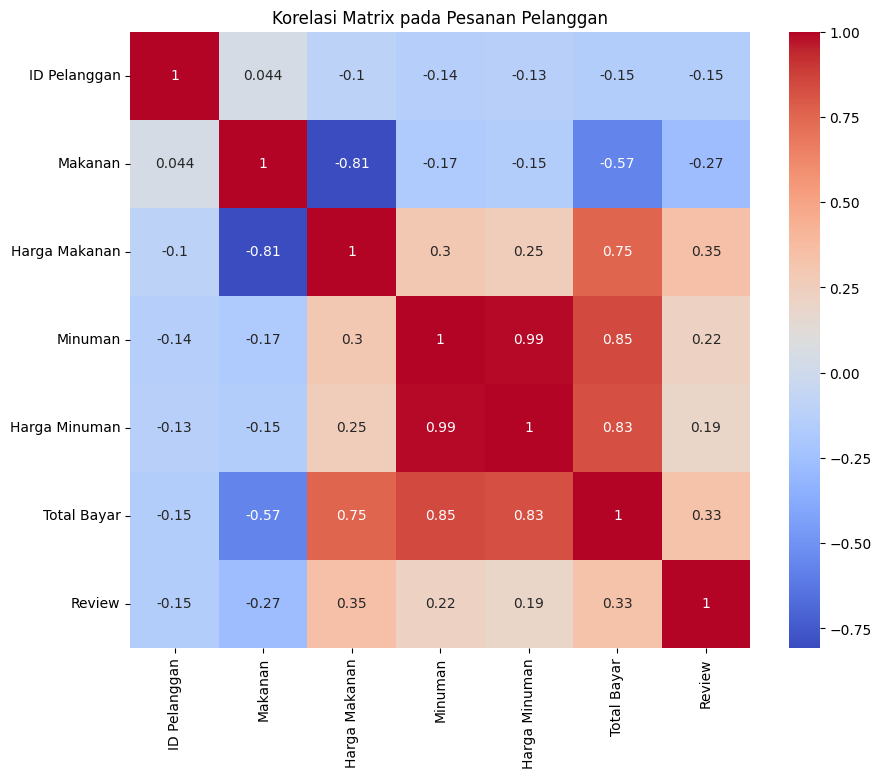

In [ ]:
corr_matrix = df[['ID Pelanggan', 'Makanan', 'Harga Makanan', 'Minuman', 'Harga Minuman', 'Total Bayar', 'Review']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Korelasi Matrix pada Pesanan Pelanggan')
plt.show()

#Visualisasi

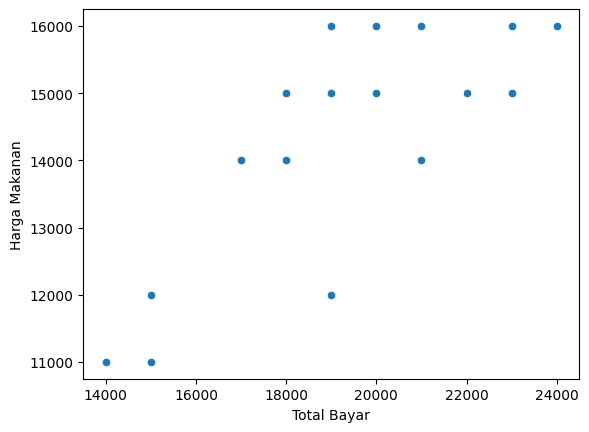

In [ ]:
sns.scatterplot(x=df['Total Bayar'], y=df['Harga Makanan'])
plt.show()

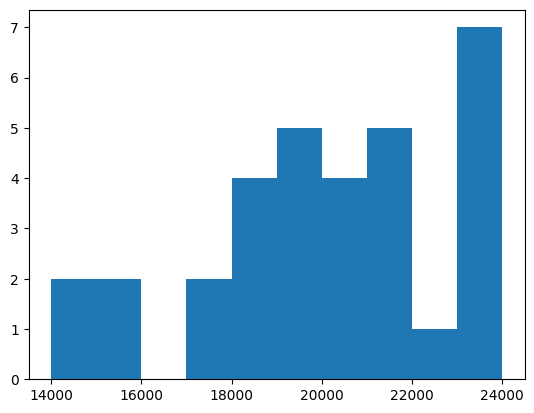

In [ ]:
df_hist = df['Total Bayar']
plt.hist(df_hist)
plt.show()

#Challenge

In [ ]:
dataFrame = pd.read_csv("https://raw.githubusercontent.com/RachmasariAR/Pelatihan4_DS/refs/heads/main/car_price_dataset.csv")
dataFrame

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
...,...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084
